In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report


In [2]:
# Load the dataset
file_path = "E:/Data Science/12-KNN/glass.csv"  
glass_data = pd.read_csv(file_path)

# Display the first few rows to verify data loading
glass_data

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0,1
...,...,...,...,...,...,...,...,...,...,...
209,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0,7
210,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0,7
211,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0,7
212,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.0,7


In [3]:
# Get dataset info and check for missing values
print(glass_data.info())
print(glass_data.describe())

# Check for duplicates
duplicates = glass_data.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# Remove duplicates if any
glass_data = glass_data.drop_duplicates()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB
None
               RI          Na          Mg          Al          Si           K  \
count  214.000000  214.000000  214.000000  214.000000  214.000000  214.000000   
mean     1.518365   13.407850    2.684533    1.444907   72.650935    0.497056   
std      0.003037    0.816604    1.442408    0.499270    0.774546    0.652192   
min      1.511150   10.730000    0.000000    0.290000   69.810000    0.

In [4]:
# Separate features (X) and target variable (y)
X = glass_data.drop(columns=['Type'])
y = glass_data['Type']

# Apply standard scaling to features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

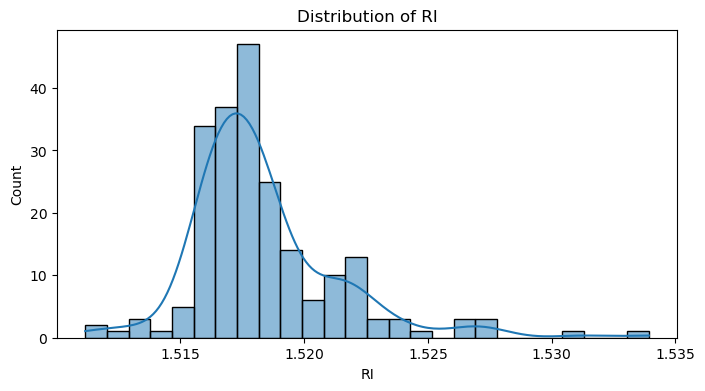

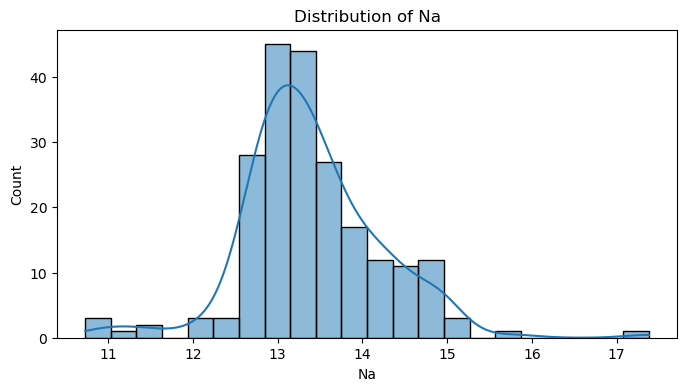

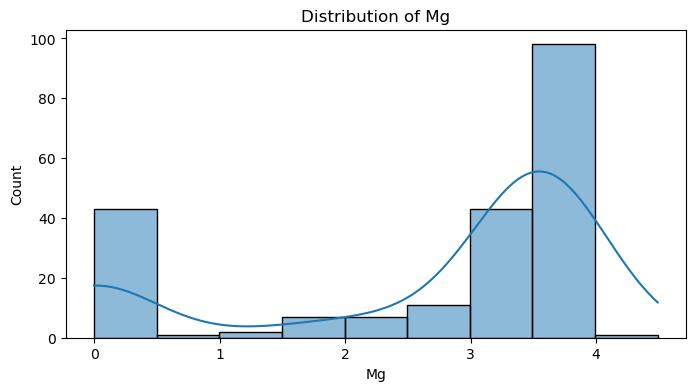

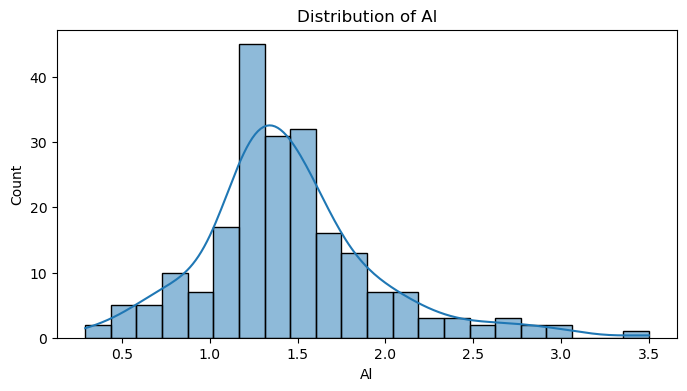

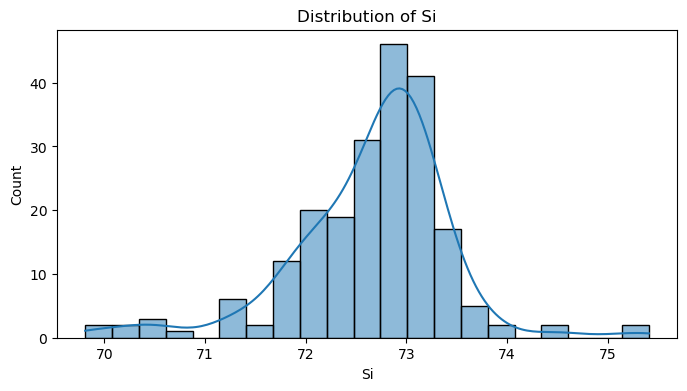

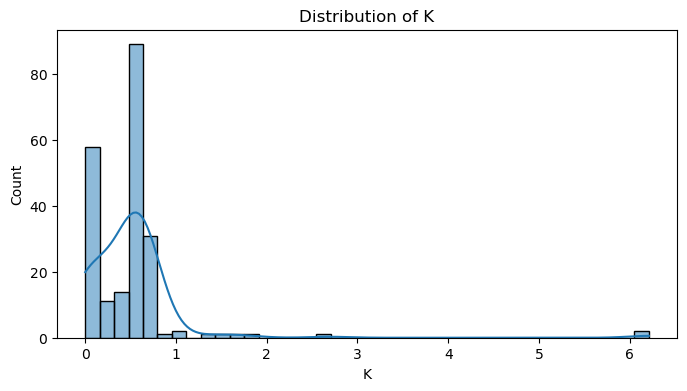

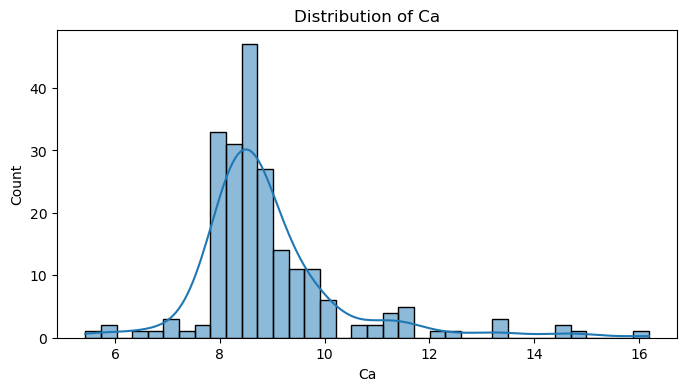

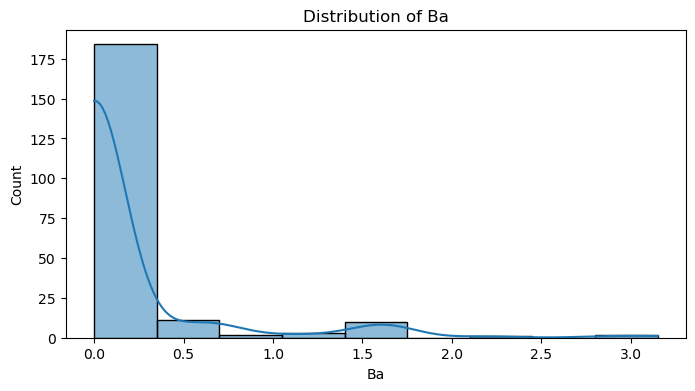

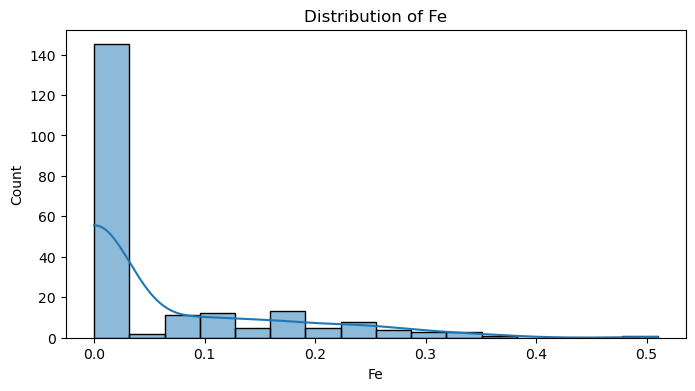

In [9]:
for col in X.columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(glass_data[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

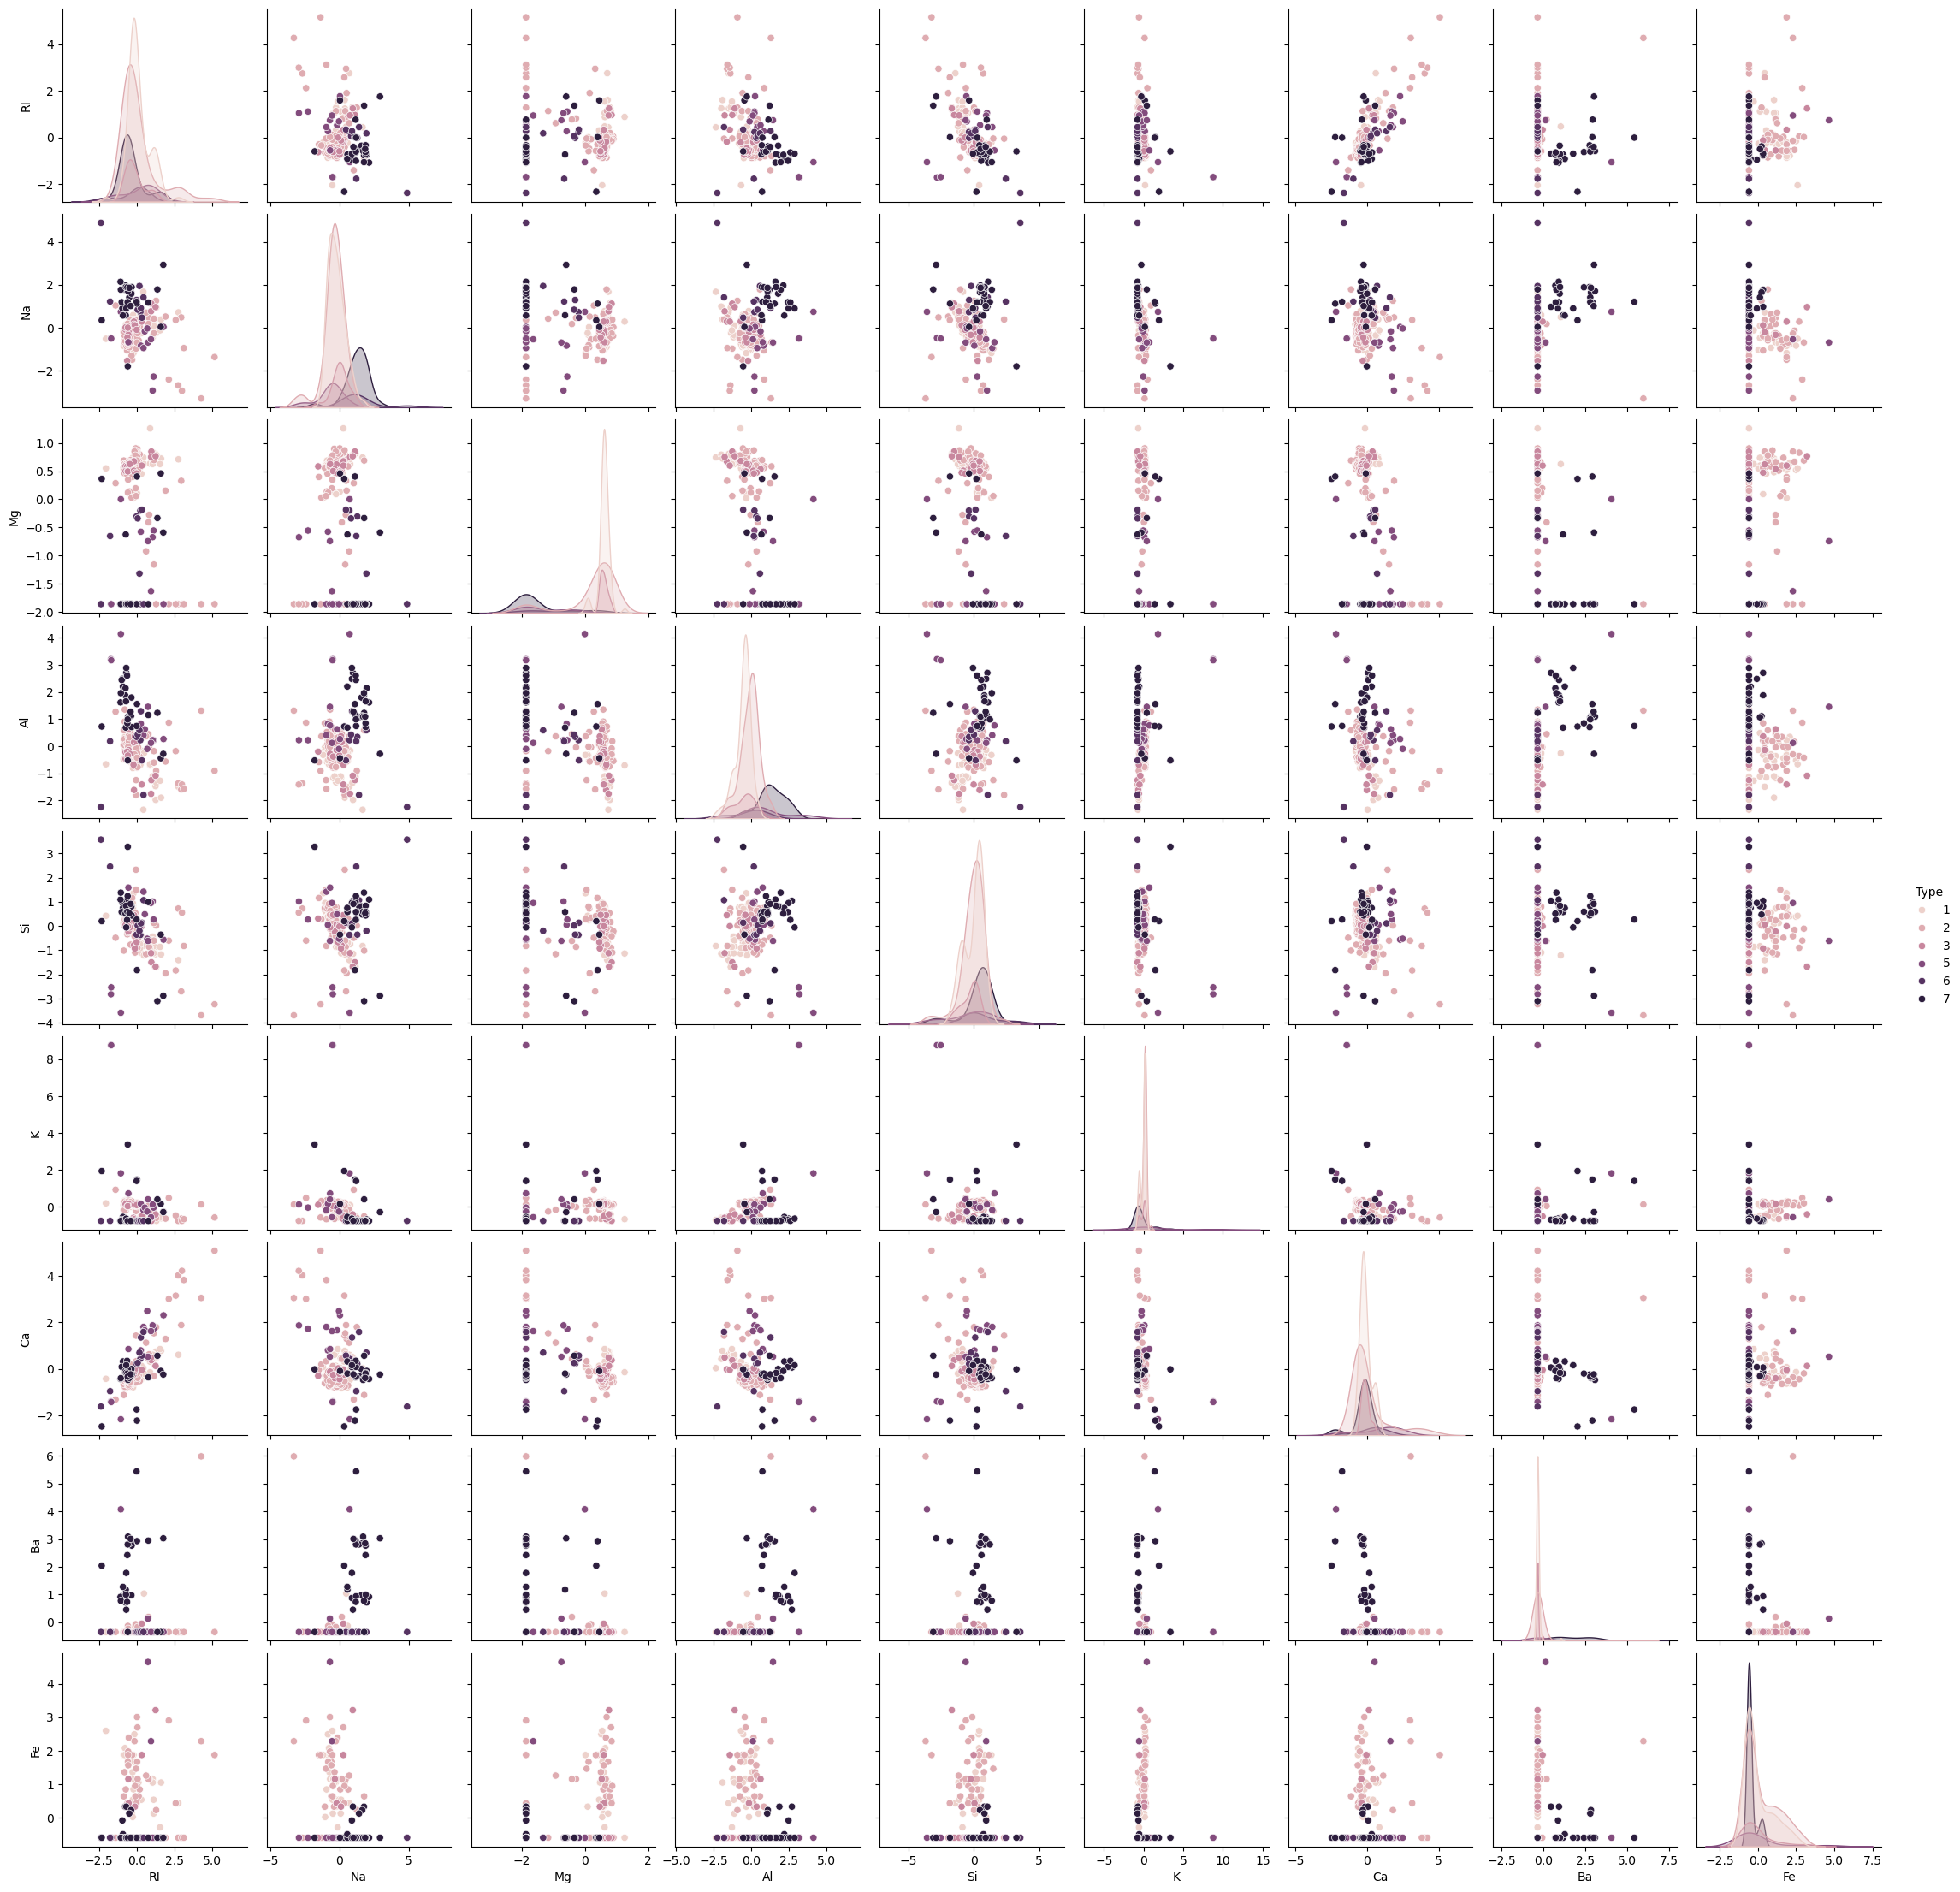

In [11]:
sns.pairplot(pd.concat([pd.DataFrame(X_scaled, columns=X.columns), y.reset_index(drop=True)], axis=1), hue="Type")
plt.show()


In [12]:
# Trying different values of K to find the optimal one
accuracy_scores = []
for k in range(1, 20):
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_scaled, y, cv=5)
    accuracy_scores.append(scores.mean())

# Find the K value with the highest accuracy
optimal_k = np.argmax(accuracy_scores) + 1
print(f"Optimal K value: {optimal_k}")

Optimal K value: 2


In [15]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Build and train the model with the optimal K
knn = KNeighborsClassifier(n_neighbors=optimal_k)
knn.fit(X_train, y_train)

# Make predictions on the test set
y_pred = knn.predict(X_test)

# Evaluate model performance
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Precision: {precision_score(y_test, y_pred, average='weighted')}")
print(f"Recall: {recall_score(y_test, y_pred, average='weighted')}")
print(classification_report(y_test, y_pred))


Accuracy: 0.671875
Precision: 0.6614583333333333
Recall: 0.671875
              precision    recall  f1-score   support

           1       0.59      0.89      0.71        18
           2       0.62      0.62      0.62        24
           3       0.00      0.00      0.00         4
           5       0.67      0.50      0.57         4
           6       1.00      0.67      0.80         3
           7       1.00      0.73      0.84        11

    accuracy                           0.67        64
   macro avg       0.65      0.57      0.59        64
weighted avg       0.66      0.67      0.65        64



C:\Users\samir\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\samir\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\samir\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\samir\anaconda3\Lib\site-packag

benefits to the glass manufacturing plant:

Efficiency Gains by automating classification.
Cost Reduction in labor and potential error correction.
Consistency in Quality by standardizing the classification process.